In [1]:
import pandas as pd
import os

In [2]:
# for reviewer responses IJSTS

dir = "/home/csutter/DRIVE-clean/ensembling/data_preds"

predscsv = os.listdir(dir)

trackers = [f"{dir}/{i}" for i in predscsv]

trackers

['/home/csutter/DRIVE-clean/ensembling/data_preds/modelFinal_OT2.csv',
 '/home/csutter/DRIVE-clean/ensembling/data_preds/modelFinal_OT3.csv',
 '/home/csutter/DRIVE-clean/ensembling/data_preds/modelFinal_OT5.csv',
 '/home/csutter/DRIVE-clean/ensembling/data_preds/modelFinal_OT0.csv',
 '/home/csutter/DRIVE-clean/ensembling/data_preds/modelFinal_OT1.csv',
 '/home/csutter/DRIVE-clean/ensembling/data_preds/modelFinal_OT4.csv']

In [3]:
d = pd.read_csv("/home/csutter/DRIVE-clean/ensembling/data_preds/modelFinal_OT2.csv")

d.head(4)

for c in d.columns:
    print(c)

Unnamed: 0
index
Unnamed: 0.2
Unnamed: 0.1
m0_innerPhase
outerPhase
img_name
img_orig
site
img_cat
foldnum
timeofday
timeofevent
m0_calib_prob_dry
m0_calib_prob_poor_viz
m0_calib_prob_snow
m0_calib_prob_snow_severe
m0_calib_prob_wet
m0_calib_prob
img_orig_hrrr
img_index
Latitude
Longitude
yr
mo
day
date
time
ymd
date_and_time_str
date_and_time_dt
date_and_time_dt_round
date_and_time_dt_init
init_hr
init_year
init_month
init_day
init_yyyymmdd
hrrr_file
HRRR_latlon
HRRR_distkm
time.1
valid_time
latitude
longitude
t2m
pt
sh2
d2m
r2
u10
v10
si10
asnow
tp
orog
cape
mslma
dswrf
dlwrf
tcc
gh
dpt
atmosphere
isobaricInhPa
uavg
o_prob_dry
o_prob_poor_viz
o_prob_snow
o_prob_snow_severe
o_prob_wet
o_pred
o_prob
classifier_TF
classifier_01
o_prob_calib
m0_calib_pred
m1_calib_prob_dry
m1_calib_prob_poor_viz
m1_calib_prob_snow
m1_calib_prob_snow_severe
m1_calib_prob_wet
m1_calib_pred
m1_calib_prob
m2_calib_prob_dry
m2_calib_prob_poor_viz
m2_calib_prob_snow
m2_calib_prob_snow_severe
m2_calib_prob_wet


In [4]:
dfslist = []

for t in trackers:
    d = pd.read_csv(t)
    print(len(d))
    dfslist.append(d)

df = pd.concat(dfslist)

display(df.head(4))

print(sum(df["select_correct"])/len(df))

print(len(df))

3337
3773
3576
3697
3561
3545


,Unnamed: 0,index,Unnamed: 0.2,Unnamed: 0.1,m0_innerPhase,outerPhase,img_name,img_orig,site,img_cat,...,ensembleAvg_predprob,ensembleMode_pred,ensembleMaxConf_pred,methodalign_1_2,methodalign_1_3,methodalign_2_3,select,decision,select_correct,ok_select
0,0,7066,7066,7066,NAOuterTest,outerTest,495_Eastbound_at_Exits_65_66_Rest_Area_(Fixed)...,/DRIVE/site_analysis/corridor_LIE_east/gui_lab...,Skyline_1970,dry,...,0.941551,dry,dry,True,True,True,dry,align_avg_mode,True,True
1,1,7067,7067,7067,NAOuterTest,outerTest,495_Eastbound_at_Exits_65_66_Rest_Area_(Fixed)...,/DRIVE/site_analysis/corridor_LIE_east/gui_lab...,Skyline_1970,dry,...,0.951726,dry,dry,True,True,True,dry,align_avg_mode,True,True
2,2,7068,7068,7068,NAOuterTest,outerTest,495_Eastbound_at_Exits_65_66_Rest_Area_(Fixed)...,/DRIVE/site_analysis/corridor_LIE_east/gui_lab...,Skyline_1970,dry,...,0.927264,dry,dry,True,True,True,dry,align_avg_mode,True,True
3,3,7069,7069,7069,NAOuterTest,outerTest,495_Eastbound_at_Exits_65_66_Rest_Area_(Fixed)...,/DRIVE/site_analysis/corridor_LIE_east/gui_lab...,Skyline_1970,dry,...,0.934723,dry,dry,True,True,True,dry,align_avg_mode,True,True


0.8153473870352274
21489


# Precision recall stats for table

In [10]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report


# Compute overall (macro-averaged) precision, recall, F1
precision = precision_score(df['img_cat'], df['select'], average='macro')
recall = recall_score(df['img_cat'], df['select'], average='macro')
f1 = f1_score(df['img_cat'], df['select'], average='macro')

print(f"Overall Precision: {precision:.5f}")
print(f"Overall Recall: {recall:.5f}")
print(f"Overall F1: {f1:.5f}")

# Optional: detailed per-class metrics
print("\nPer-class report:")
# print(classification_report(df['img_cat'], df['select']))
print(classification_report(df['img_cat'], df['select'], digits=4))



Overall Precision: 0.76631
Overall Recall: 0.80279
Overall F1: 0.78176

Per-class report:
              precision    recall  f1-score   support

         dry     0.8441    0.9014    0.8719      7600
    poor_viz     0.6420    0.7683    0.6995       915
        snow     0.6800    0.7705    0.7224      2989
 snow_severe     0.7873    0.8147    0.8008      1527
         wet     0.8781    0.7590    0.8143      8458

    accuracy                         0.8153     21489
   macro avg     0.7663    0.8028    0.7818     21489
weighted avg     0.8220    0.8153    0.8160     21489



# Make precision recall plots

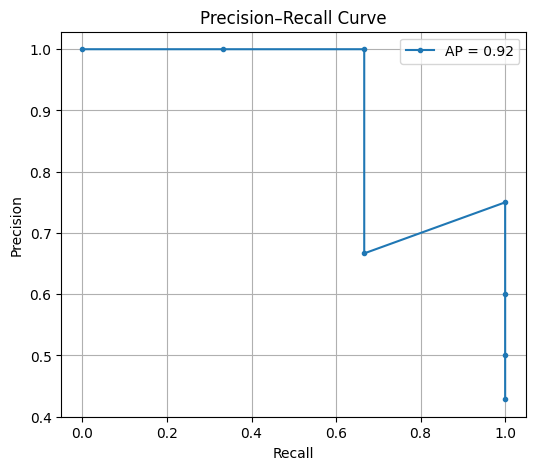

In [11]:
# Example from chat gpt

import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Example data
y_true = np.array([0, 0, 1, 1, 0, 1, 0])
y_pred = np.array([0, 0, 1, 1, 0, 0, 1])
y_prob = np.array([0.2, 0.1, 0.9, 0.8, 0.3, 0.4, 0.7])

# Compute precision-recall pairs for different probability thresholds
precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

# Compute the average precision score (area under curve)
ap = average_precision_score(y_true, y_prob)

# Plot Precision-Recall curve
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, marker='.', label=f'AP = {ap:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

1580
[22, 23, 24, 25]
0.7997558690001233


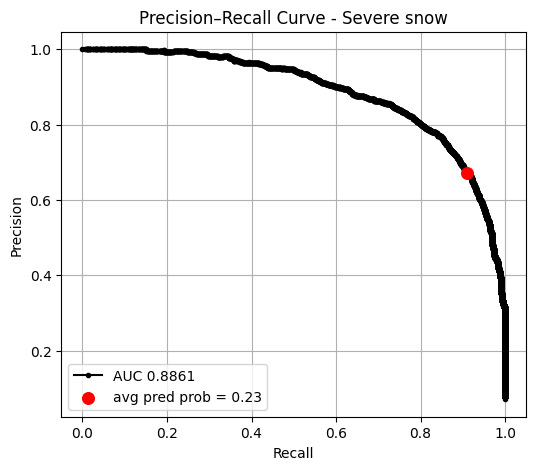

3387
[27, 30, 31, 32]
0.7006909563683384


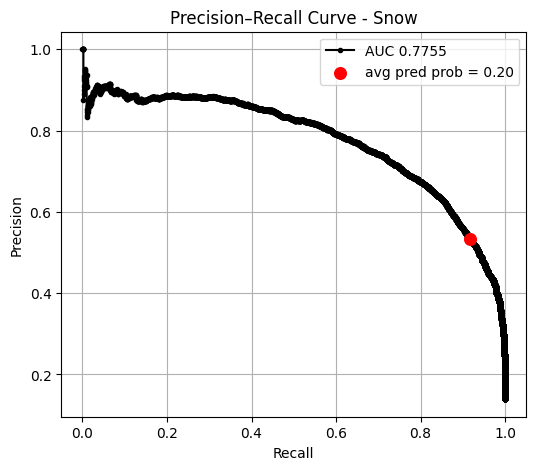

7311
[88, 89, 90, 91]
0.8116669436866822


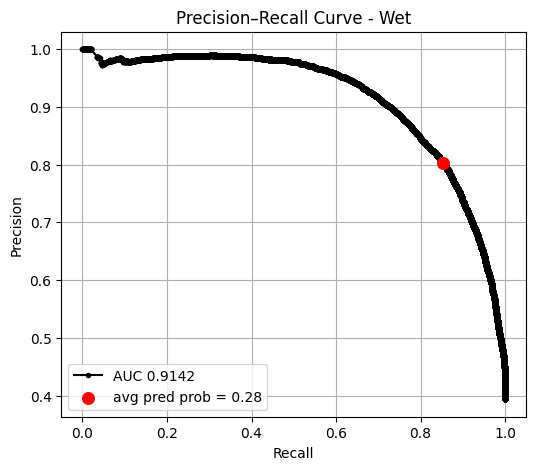

8116
[0, 1, 2, 3]
0.807489938245407


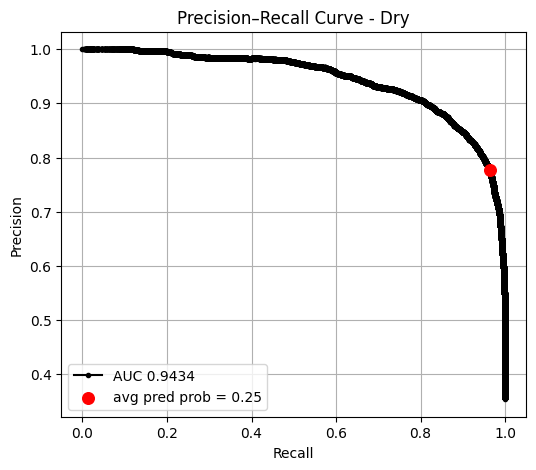

1095
[72, 73, 74, 75]
0.7455118209898848


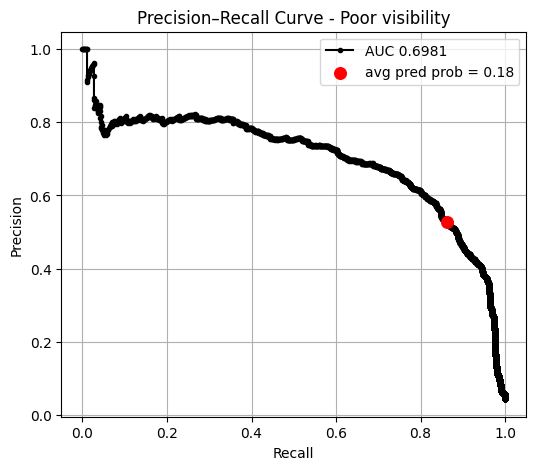

In [14]:
# prep for one vs all precision recall curves

# 1s and 0s for labeled cat
df['onevall_imgcat_ss'] = np.where(df['img_cat'] =="snow_severe", 1, 0)
df['onevall_imgcat_s'] = np.where(df['img_cat'] =="snow", 1, 0)
df['onevall_imgcat_w'] = np.where(df['img_cat'] =="wet", 1, 0)
df['onevall_imgcat_d'] = np.where(df['img_cat'] =="dry", 1, 0)
df['onevall_imgcat_pv'] = np.where(df['img_cat'] =="poor_viz", 1, 0)

# 1s and 0s for model preds
df['onevall_pred_ss'] = np.where(df['select'] =="snow_severe", 1, 0)
df['onevall_pred_s'] = np.where(df['select'] =="snow", 1, 0)
df['onevall_pred_w'] = np.where(df['select'] =="wet", 1, 0)
df['onevall_pred_d'] = np.where(df['select'] =="dry", 1, 0)
df['onevall_pred_pv'] = np.where(df['select'] =="poor_viz", 1, 0)

def plot_prec_recall(classname, y_prob, y_true = df['onevall_imgcat_ss'], y_pred = df['onevall_pred_ss']):

    # Format data
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    # Compute precision-recall pairs for different probability thresholds
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    # Compute the average precision score (area under curve)
    ap = average_precision_score(y_true, y_prob)

    # also add in the average point, i.e. the avg prob where that class is actually predicted (plotting this point is strange tho bc the mean/median is quite high, but plotting that on our plot as if it was a "cutoff" point is quite misleading bc that's a high bar and makes precision look a higher priority than recall. Alternatively, plotting the min is also odd bc it's just one point and that is more a function of the fact that we have 5 classes)
    # Comment chunk out if don't want to show dot on plot (SPOT 1)
    correctpreds = [i for i, x in enumerate(y_pred) if x == 1]
    print(len(correctpreds))
    print(correctpreds[0:4])
    correctpreds_probs = y_prob[correctpreds]
    print(np.mean(correctpreds_probs))
    pr = np.min(correctpreds_probs)

    # Plot Precision–Recall curve
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, marker='.', color='black', label=f'AUC {ap:.4f}')

    # Comment chunk out if don't want to show dot on plot (SPOT 2)
    idx = np.argmin(np.abs(thresholds - pr))
    plt.scatter(recall[idx], precision[idx],
                color='red', s=70, zorder=5,
                label=f'avg pred prob = {pr:.2f}')


    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision–Recall Curve - {classname}')
    plt.legend()
    plt.grid(True)
    plt.show()



plot_prec_recall(classname = "Severe snow", y_prob = df['ensembleAvg_snow_severe'], y_true = df['onevall_imgcat_ss'], y_pred = df['onevall_pred_ss'])

plot_prec_recall(classname = "Snow", y_prob = df['ensembleAvg_snow'], y_true = df['onevall_imgcat_s'], y_pred = df['onevall_pred_s'])

plot_prec_recall(classname = "Wet", y_prob = df['ensembleAvg_wet'], y_true = df['onevall_imgcat_w'], y_pred = df['onevall_pred_w'])

plot_prec_recall(classname = "Dry", y_prob = df['ensembleAvg_dry'], y_true = df['onevall_imgcat_d'], y_pred = df['onevall_pred_d'])

plot_prec_recall(classname = "Poor visibility", y_prob = df['ensembleAvg_poor_viz'], y_true = df['onevall_imgcat_pv'], y_pred = df['onevall_pred_pv'])